In [1]:
# ====================================================
# Libraries
# ====================================================

import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp, trapezoid, cumulative_trapezoid
from scipy.interpolate import RegularGridInterpolator
from scipy.special import erf
from multiprocessing import Pool
import os
import time
import emcee
from getdist import MCSamples, plots
import matplotlib.pyplot as plt
from scipy.stats import chi2 as chi2_dist

In [2]:
# =========================
# Loading CC data
# =========================

cc_dat_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/CC/CC_Hz_data.txt"
df_cc = pd.read_csv(cc_dat_path, sep=r"\s+")
z_cc   = df_cc["z_cc"].to_numpy(float)
H_obs  = df_cc["H_cc"].to_numpy(float)
H_err   = df_cc["H_cc_err"].to_numpy(float)


# =========================
# Loading SNe Ia data (Pantheon+SH0ES)
# =========================

sne_dat_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/SNe/Pantheon+SH0ES.dat"
sne_cov_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/SNe/Pantheon+SH0ES_STAT+SYS.cov"
df_sne = pd.read_csv(sne_dat_path, sep=r"\s+", comment="#", engine="python")
raw_cov = np.loadtxt(sne_cov_path, skiprows=1)
Cov_sne_full = raw_cov.reshape((1701, 1701))
mask = df_sne["zCMB"].values > 0.01
df_cut = df_sne[mask].reset_index(drop=True)
Cov_sne = Cov_sne_full[mask, :][:, mask]
z_sne = df_cut["zCMB"].values
mB_obs = df_cut["m_b_corr"].values
Cinv_sne = np.linalg.inv(Cov_sne)


# ====================================================
# Loading BAO data (DESI_DR2)
# ====================================================

bao_dat_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/BAO/desi_gaussian_bao_ALL_GCcomb_mean.txt"
bao_cov_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/BAO/desi_gaussian_bao_ALL_GCcomb_cov.txt"
df_bao = pd.read_csv(bao_dat_path, sep=r"\s+", comment="#", names=["z", "value", "quantity"])
z_bao = df_bao["z"].values
d_obs = df_bao["value"].values
q_bao = df_bao["quantity"].str.lower().values
cov_bao  = np.loadtxt(bao_cov_path)
Cinv_bao = np.linalg.inv(cov_bao)


# =========================
# Loading FRB data
# =========================

frb_dat_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/FRB/frb_catalog.txt"
df_frb = pd.read_csv(frb_dat_path, sep=r"\t", engine='python')
df_frb = df_frb.sort_values(by="Redshift", ascending=True)
df_frb = df_frb.reset_index(drop=True)
z_frb   = df_frb["Redshift"].to_numpy(float)
DM_obs  = df_frb["DM_obs"].to_numpy(float)
DM_MW   = df_frb["DM_MW_ISM_(NE2001)"].to_numpy(float)
DM_halo_mean = 50
DM_MW_total = DM_MW + DM_halo_mean
DM_ext_obs = DM_obs - DM_MW_total

In [3]:
# ====================================================
# Fiducial / Priors
# ====================================================
 
# Hard bounds
H0_min,       H0_max       = 50.0,   90.0
Om0_min,      Om0_max      = 0.1,    0.6
Ob_min,       Ob_max       = 0.01,   0.1
MB_min,       MB_max       = -20.0,  -18.0
mu_HS_min,    mu_HS_max    = 0.0,    300.0
sig_host_min, sig_host_max = 0.2,    2.0
e_mu_min,     e_mu_max     = 20.0,   200.0

# Physical constants
c_kms = 299792.458         # speed of light [km/s]
c_si = 2.99792458e8        # speed of light [m/s] (SI)
G_si = 6.67430e-11
mp_si = 1.67262192369e-27

# Cosmological/astrophysical parameters
f_IGM = 0.83
chi_e = 0.875
Neff  = 3.046

# HS model index (fixed)
n = 1

# Scalaron mass scale
delta_s = 1e-7

# Unit conversion factors
km_to_pc = 1.0 / (3.0857e13)
m2_to_cm2 = 1e4
Mpc_to_cm = 3.0857e24


# ====================================================
# Redshift / scale-factor / number of e-folds grids
# ====================================================

ai,    af    = 0.2,        1.0
zi,    zf    = 0.0,        4.0
ln_ai, ln_af = np.log(ai), np.log(af)

N_grid = 300
z_grid = np.linspace(zi, zf, N_grid)
dz     = np.diff(z_grid)  

In [4]:
# ====================================================
# Custom exception for ODE failure
# ====================================================

class ODEFailure(Exception):
    pass


# ====================================================
# ODE system for yH(t=lna) in HS f(R) gravity
# ====================================================

def yH_HS_ode(lna, y, H0, Om0, mu_HS):
    
    yH, YH = y                    # yH = yH(lna) | YH = dyH/d(lna)

    a = np.exp(lna)               
    
    ms  = H0**2 * Om0
    Lbd = 3.0 * H0**2 * (1.0 - Om0)
    M2  = ms / delta_s
    
    R   = 3.0 * ms * ( YH + ( 4 * yH ) + a**(-3) )
    
    An  = R**n + mu_HS**(2*n)
    Bn  = R**n
    Cn  = (n + 1) * R**(2*n - 2) - (n - 1) * mu_HS**(2*n) * R**(n - 2)
    Dn  = An**3
    
    f_R = R - 2.0 * Lbd * (Bn / An) + (R**2) / (6 * M2)
    fR  = 1.0 - 2.0 * n * Lbd * mu_HS**(2*n) * (Bn / An) * (1.0 / (R * An)) + R / (3 * M2)
    fRR = 2.0 * n * Lbd * mu_HS**(2*n) * (Cn / Dn) + 1 / (3 * M2)
    
    if fRR == 0.0 or not np.isfinite(fRR):
        raise ODEFailure(f"fRR singular at lna={lna:.4f}")
    
    
    yaux1 = yH + a**(-3)
    yaux2 = a**(-3)
    yaux3 = ( (1 - fR) * yaux2 ) + ( (R - f_R) / (3 * ms) )
    
    J1 = 4.0 + (1.0 / yaux1) * ( (1.0 - fR) / (6.0 * ms * fRR) )
    J2 = (1.0 / yaux1) * ( (2.0 - fR) / (3.0 * ms * fRR) )
    J3 = - ( 3.0 * yaux2 ) - ( yaux3 / yaux1) * ( 1.0 / (6.0 * ms * fRR) )
    
    dYH = - J1 * YH - J2 * yH - J3
    return [YH, dYH]


# ====================================================
# ODE integration → H(lna)
# ====================================================

def H_HS_lna(lna_eval, H0, Om0, mu_HS):
    ms  = H0**2 * Om0
    yH0 = (1.0 - Om0) / Om0
    YH0 = 0.0
    y0  = [yH0, YH0]
    try:
        sol = solve_ivp(
            yH_HS_ode,
            (ln_ai, ln_af),
            y0,
            t_eval=lna_eval,
            method="LSODA",
            rtol=1e-6,
            atol=1e-8,
            args=(H0, Om0, mu_HS),
            dense_output=False
        )
    except Exception:
        return None
    if sol.status < 0 or np.any(~np.isfinite(sol.y)):
        return None
    a_eval = np.exp(lna_eval)
    yH_sol = sol.y[0]
    H_sol  = np.sqrt(ms * (yH_sol + a_eval**(-3)))
    return H_sol


# ====================================================
# H(z) via lna = - ln(1+z) conversion
# ====================================================

def H_HS_z(z_eval, H0, Om0, mu_HS):
    z_eval    = np.atleast_1d(np.asarray(z_eval, dtype=float))
    lna_eval  = - np.log(1.0 + z_eval)
    in_domain = (lna_eval >= ln_ai) & (lna_eval <= ln_af)
    if not np.any(in_domain):
        return None
    valid_idx   = np.where(in_domain)[0]
    lna_valid   = lna_eval[valid_idx]
    sort_idx    = np.argsort(lna_valid)
    lna_sorted  = lna_valid[sort_idx]
    unique_mask = np.concatenate(([True], np.diff(lna_sorted) > 1e-12))
    lna_unique  = lna_sorted[unique_mask]
    H_unique    = H_HS_lna(lna_unique, H0, Om0, mu_HS)
    if H_unique is None:
        return None
    if not np.all(unique_mask):
        H_at_sorted = np.interp(lna_sorted, lna_unique, H_unique)
    else:
        H_at_sorted = H_unique
    H_valid           = np.empty(len(lna_valid))
    H_valid[sort_idx] = H_at_sorted
    H_z               = np.full(len(z_eval), np.nan)
    H_z[valid_idx]    = H_valid
    return H_z

In [5]:
# # ====================================================
# # Worker function (module level — required for pickle)
# # ====================================================

# def _grid_worker_HS(args):
#     """
#     Computes H(z) for a single (H0, Om0, mu_HS) grid point.
#     The grid is always built in LINEAR mu_HS space.
#     Returns (i, j, k, H_values) or (i, j, k, None) on failure.
#     """
    
#     i, j, k, H0, Om0, mu_HS, z_pts = args
#     Hvals = H_HS_z(z_pts, H0, Om0, mu_HS)
#     if Hvals is not None and np.all(np.isfinite(Hvals)):
#         return (i, j, k, Hvals)
#     else:
#         return (i, j, k, None)


# # ====================================================
# # Parallel grid builder
# # ====================================================

# def build_H_grid_parallel_HS(H0_pts, Om0_pts, mu_HS_pts, z_pts,
#                               n_cores=None, verbose=True):
#     nH    = len(H0_pts)
#     nOm   = len(Om0_pts)
#     nmu   = len(mu_HS_pts)
#     nz    = len(z_pts)
#     total = nH * nOm * nmu
#     n_cores = n_cores or os.cpu_count()
#     tasks = [
#         (i, j, k, H0, Om0, mu_HS, z_pts)
#         for i, H0    in enumerate(H0_pts)
#         for j, Om0   in enumerate(Om0_pts)
#         for k, mu_HS in enumerate(mu_HS_pts)
#     ]
#     H_array   = np.full((nH, nOm, nmu, nz), np.nan)
#     nan_count = 0
#     if verbose:
#         print(f"  HS model index    : n = {n}")
#         print(f"  Total grid points : {total} ({nH}×{nOm}×{nmu})")
#         print(f"  Workers           : {n_cores}")
#         print(f"  {'PCT':>5}  {'Done':>8}  {'Elapsed':>9}  {'ETA':>9}  {'Rate':>12}")
#         print("  " + "-"*55)
#     t0       = time.time()
#     count    = 0
#     last_pct = -1
#     chunksize = max(1, total // (n_cores * 20))
#     with Pool(processes=n_cores) as pool:
#         for result in pool.imap_unordered(_grid_worker_HS, tasks,
#                                           chunksize=chunksize):
#             i, j, k, Hvals = result
#             if Hvals is not None:
#                 H_array[i, j, k, :] = Hvals
#             else:
#                 nan_count += 1
#             count   += 1
#             elapsed  = time.time() - t0
#             pct      = int(count / total * 100)
#             if verbose and (pct >= last_pct + 10 or count == total):
#                 eta  = (elapsed / count) * (total - count) if count < total else 0.0
#                 rate = count / elapsed if elapsed > 0 else 0.0
#                 print(f"  {pct:>4}%  {count:>8}/{total}  "
#                       f"{elapsed:>7.1f}s  "
#                       f"ETA {eta:>6.1f}s  "
#                       f"{rate:>8.1f} pts/s")
#                 last_pct = pct
#     nan_frac = nan_count / total
#     if nan_frac > 0:
#         print(f"\n  ⚠  {100*nan_frac:.1f}% NaN in grid — "
#               f"check prior bounds or ODE stability.")
#     else:
#         print(f"\n  ✓  Grid complete with no NaN points.")
#     total_time = time.time() - t0
#     print(f"  Total time: {total_time:.1f}s ({total_time/60:.2f} min)")
#     return H_array


# # ====================================================
# # Interpolation error validation
# # ====================================================

# def validate_interpolation_error_HS(H_interp_4D, H0_pts, Om0_pts, mu_HS_pts, z_pts,
#                                     n_test=300, tol_percent=0.5):
#     """
#     Validates the interpolator against direct ODE solutions at
#     n_test random interior points (sampled in LINEAR mu_HS space).
#     """
    
#     rng_v  = np.random.default_rng(0)
#     errors = []
#     for _ in range(n_test):
#         H0_t    = rng_v.uniform(H0_pts[1],    H0_pts[-2])
#         Om0_t   = rng_v.uniform(Om0_pts[1],   Om0_pts[-2])
#         mu_HS_t = rng_v.uniform(mu_HS_pts[1], mu_HS_pts[-2])
#         H_true  = H_HS_z(z_pts, H0_t, Om0_t, mu_HS_t)
#         if H_true is None or not np.all(np.isfinite(H_true)):
#             continue
#         pts      = np.column_stack([np.full(len(z_pts), H0_t),
#                                     np.full(len(z_pts), Om0_t),
#                                     np.full(len(z_pts), mu_HS_t),
#                                     z_pts])
#         H_interp = H_interp_4D(pts)
#         rel_err  = np.abs((H_true - H_interp) / H_true) * 100.0
#         errors.append(np.max(rel_err))
#     errors = np.array(errors)
#     print(f"\n  Interpolation validation ({n_test} random interior points):")
#     print(f"  Max error    : {errors.max():.4f}%")
#     print(f"  Median error : {np.median(errors):.4f}%")
#     print(f"  95th pct     : {np.percentile(errors, 95):.4f}%")
#     if errors.max() < tol_percent:
#         print(f"  ✓  Interpolator approved (max error < {tol_percent}%). "
#               f"Ready for MCMC.")
#     else:
#         print(f"  ✗  Max error exceeds {tol_percent}%! "
#               f"Increase grid resolution (n_H0, n_Om0, n_mu_HS).")
#     return errors


# # ====================================================
# # 4D interpolation grid parameters
# # ====================================================

# n_H0    = 30
# n_Om0   = 30
# n_mu_HS = 50

# H0_grid_pts    = np.linspace(H0_min,    H0_max,    n_H0)
# Om0_grid_pts   = np.linspace(Om0_min,   Om0_max,   n_Om0)
# mu_HS_grid_pts = np.linspace(mu_HS_min, mu_HS_max, n_mu_HS)


# # ====================================================
# # Build grid (parallel)
# # ====================================================

# print(f"\n=== Building 4D interpolation grid (parallel) | HS n={n} ===")
# H_array = build_H_grid_parallel_HS(
#     H0_grid_pts, Om0_grid_pts, mu_HS_grid_pts, z_grid,
#     n_cores=os.cpu_count()
# )


# # ====================================================
# # Save grid for reuse
# # ====================================================

# np.save(f"H_array_HS_n{n}_{n_mu_HS}_grid.npy", H_array)


# # ====================================================
# # Build interpolator
# # ====================================================

# H_interp_4D = RegularGridInterpolator(
#     (H0_grid_pts, Om0_grid_pts, mu_HS_grid_pts, z_grid),
#     H_array,
#     method="linear",
#     bounds_error=False,
#     fill_value=np.nan
# )


# # ====================================================
# # Validate interpolator
# # ====================================================

# print(f"\n=== Validating interpolator | HS n={n} ===")
# errors = validate_interpolation_error_HS(
#     H_interp_4D, H0_grid_pts, Om0_grid_pts, mu_HS_grid_pts, z_grid
# )

In [6]:
# =====================================================
# Load and validation of the grid
# =====================================================

# 4D interpolation grid parameters
n_H0    = 30
n_Om0   = 30
n_mu_HS = 1000

H0_grid_pts    = np.linspace(H0_min,    H0_max,    n_H0)
Om0_grid_pts   = np.linspace(Om0_min,   Om0_max,   n_Om0)
mu_HS_grid_pts = np.linspace(mu_HS_min, mu_HS_max, n_mu_HS)

# Load grid from file
H_array_path = "/home/brunowesley/projetos/MCMC-cosmo/Codes/MG-based/Hu-Sawicki/CC/H_array_HS_n1_1k_grid.npy"
H_array = np.load(H_array_path)

# Build interpolator
H_interp_4D = RegularGridInterpolator(
    (H0_grid_pts, Om0_grid_pts, mu_HS_grid_pts, z_grid),
    H_array,
    method="linear",
    bounds_error=False,
    fill_value=np.nan
)

# Interpolation error validation
def validate_interpolation_error_HS(H_interp_4D, H0_pts, Om0_pts, mu_HS_pts, z_pts,
                                    n_test=300, tol_percent=0.5):
    rng_v  = np.random.default_rng(0)
    errors = []
    for _ in range(n_test):
        H0_t    = rng_v.uniform(H0_pts[1],    H0_pts[-2])
        Om0_t   = rng_v.uniform(Om0_pts[1],   Om0_pts[-2])
        mu_HS_t = rng_v.uniform(mu_HS_pts[1], mu_HS_pts[-2])
        H_true  = H_HS_z(z_pts, H0_t, Om0_t, mu_HS_t)
        if H_true is None or not np.all(np.isfinite(H_true)):
            continue
        pts      = np.column_stack([np.full(len(z_pts), H0_t),
                                    np.full(len(z_pts), Om0_t),
                                    np.full(len(z_pts), mu_HS_t),
                                    z_pts])
        H_interp = H_interp_4D(pts)
        rel_err  = np.abs((H_true - H_interp) / H_true) * 100.0
        errors.append(np.max(rel_err))
    errors = np.array(errors)
    print(f"\n  Interpolation validation ({n_test} random interior points):")
    print(f"  Max error    : {errors.max():.4f}%")
    print(f"  Median error : {np.median(errors):.4f}%")
    print(f"  95th pct     : {np.percentile(errors, 95):.4f}%")
    if errors.max() < tol_percent:
        print(f"  ✓  Interpolator approved (max error < {tol_percent}%). "
              f"Ready for MCMC.")
    else:
        print(f"  ✗  Max error exceeds {tol_percent}%! "
              f"Increase grid resolution (n_H0, n_Om0, n_mu_HS).")
    return errors

# Validate
print(f"\n=== Validating interpolator | HS n={n} ===")
errors = validate_interpolation_error_HS(
    H_interp_4D, H0_grid_pts, Om0_grid_pts, mu_HS_grid_pts, z_grid
)


=== Validating interpolator | HS n=1 ===

  Interpolation validation (300 random interior points):
  Max error    : 0.1029%
  Median error : 0.0053%
  95th pct     : 0.0293%
  ✓  Interpolator approved (max error < 0.5%). Ready for MCMC.


In [7]:
# ====================================================
# H(z) via interpolator — used inside MCMC
# ====================================================

def H_HS_interp(z_eval, H0, Om0, mu_HS):
    """Query interpolator with physical (linear) mu_HS."""
    
    pts = np.column_stack([
        np.full(len(z_eval), H0),
        np.full(len(z_eval), Om0),
        np.full(len(z_eval), mu_HS),
        z_eval
    ])
    return H_interp_4D(pts)

    
# ====================================================
# Apparent magnitude (interpolated) — used inside MCMC
# ====================================================

def dL_HS_interp(z, H0, Om0, mu_HS):
    H_interp  = H_HS_interp(z_grid, H0, Om0, mu_HS)
    prefactor = c_kms * (1.0 + z)
    integrand = 1.0 / H_interp
    integral  = cumulative_trapezoid(integrand, z_grid, initial=0.0)
    I_z       = np.interp(z, z_grid, integral)
    return prefactor * I_z
    
def mB_HS_interp(z, H0, Om0, MB, mu_HS):
    dL = dL_HS_interp(z, H0, Om0, mu_HS)
    mu = 5.0 * np.log10(dL) + 25.0
    return mu + MB


# ====================================================
# BAO observables (interpolated) — used inside MCMC 
# ====================================================

def comoving_dist_interp(z, H0, Om0, mu_HS):
    H_interp     = H_HS_interp(z_grid, H0, Om0, mu_HS)
    integrand    = 1.0 / H_interp
    integral     = np.empty_like(z_grid)
    integral[0]  = 0.0
    integral[1:] = np.cumsum(0.5 * (integrand[1:] + integrand[:-1]) * dz)
    I_z          = np.interp(z, z_grid, integral)
    return c_kms * I_z

def d_bao_HS_interp(z_arr, q_arr, H0, Om0, Ob, mu_HS):
    h2   = (H0 / 100.0)**2
    Obh2 = Ob * h2
    Omh2 = Om0 * h2
    rd   = 147.05 * ((Obh2 / 0.02236)**-0.13) \
                  * ((Omh2 / 0.1432)**-0.23)  \
                  * ((Neff  / 3.04)**-0.1)
    dC  = comoving_dist_interp(z_arr, H0, Om0, mu_HS)
    H_z = H_HS_interp(z_arr, H0, Om0, mu_HS)
    dm  = dC / rd
    dh  = (c_kms / H_z) / rd
    dv  = (z_arr * dm**2 * dh)**(1.0 / 3.0)

    d_bao          = np.empty_like(z_arr)
    mask_dv        = np.array(["dv" in q for q in q_arr])
    mask_dm        = np.array(["dm" in q for q in q_arr])
    mask_dh        = np.array(["dh" in q for q in q_arr])
    d_bao[mask_dv] = dv[mask_dv]
    d_bao[mask_dm] = dm[mask_dm]
    d_bao[mask_dh] = dh[mask_dh]
    return d_bao


# ====================================================
# Interpolated DM_IGM — used inside MCMC
# ====================================================

def DM_IGM_HS_interp(z, H0, Om0, Ob, mu_HS):
    prefactor   = 3.0 * c_si * f_IGM * chi_e / (8.0 * np.pi * G_si * mp_si)
    H_grid      = H_HS_interp(z_grid, H0, Om0, mu_HS)
    integrand   = (1 + z_grid) / H_grid
    I_grid      = cumulative_trapezoid(integrand, z_grid, initial=0.0)
    I_z         = np.interp(z, z_grid, I_grid)
    DM_IGM_z    = prefactor * Ob * H0**2 * I_z
    DM_IGM_corr = DM_IGM_z * (km_to_pc / (m2_to_cm2 * Mpc_to_cm))
    return DM_IGM_corr

In [8]:
# ====================================================
# CC + SNe + BAO + FRB likelihood 
# ====================================================

def lnprior_cc_sne_bao_frb(theta):
    H0, Om0, Ob, MB, mu_HS, sigma_host, exp_mu = theta
    if not (H0_min       <= H0         <= H0_max):        return -np.inf
    if not (Om0_min      <= Om0        <= Om0_max):       return -np.inf
    if not (Ob_min       <= Ob         <= Ob_max):        return -np.inf
    if not (MB_min       <= MB         <= MB_max):        return -np.inf
    if not (mu_HS_min    <= mu_HS      <= mu_HS_max):     return -np.inf
    if not (sig_host_min <= sigma_host <= sig_host_max):  return -np.inf
    if not (e_mu_min     <= exp_mu     <= e_mu_max):      return -np.inf
    return 0.0


# Convolved FRB PDF: IGM (Gaussian) + host galaxy (log-normal)
def P_DM_ext_vectorized(z_frb, DM_ext_obs, DM_IGM_mean, sigma_IGM,
                         sigma_host, exp_mu, npts=300):
    mu_host      = np.log(exp_mu)
    upper        = max(DM_ext_obs.max(), 5.0 * exp_mu)
    DM_hosp_grid = np.linspace(1e-2, upper, npts)
    DM_hosp_grid = DM_hosp_grid[None, :]                     
    DM_ext_array      = DM_ext_obs[:, None]
    DM_IGM_array      = DM_ext_array - DM_hosp_grid / (1 + z_frb[:, None])
    sigma_IGM_array   = sigma_IGM[:, None]
    DM_IGM_mean_array = DM_IGM_mean[:, None]

    # standardized variable
    y = (DM_IGM_array - DM_IGM_mean_array) / sigma_IGM_array

    # standard normal PDF
    phi = (1/np.sqrt(2*np.pi)) * np.exp(-0.5 * y**2)

    # normalization factor: 1 - Φ(0 | μ, σ) = Φ(μ/σ)
    norm_factor = 0.5 * (1 + erf(DM_IGM_mean_array / (sigma_IGM_array * np.sqrt(2))))

    # truncated Gaussian
    P_IGM = (1 / sigma_IGM_array) * phi / norm_factor
    P_IGM[DM_IGM_array < 0] = 0.0

    DM_hosp_array = DM_hosp_grid
    P_host = (1.0 / (np.sqrt(2*np.pi) * sigma_host * DM_hosp_array)) \
             * np.exp(-0.5 * ((np.log(DM_hosp_array) - mu_host) / sigma_host)**2)

    integrand = P_IGM * P_host               
    P_total   = trapezoid(integrand, x=DM_hosp_grid[0], axis=1)
    return np.maximum(P_total, 1e-100)


# Log-likelihood
def lnlike_cc_sne_bao_frb(theta, z_cc, H_obs, H_err, 
                             z_sne, mB_obs, Cinv_sne, 
                             z_bao, d_obs, q_bao, Cinv_bao,
                             z_frb, DM_ext_obs, npts=300):
    H0, Om0, Ob, MB, mu_HS, sigma_host, exp_mu = theta
    
    # CC part
    H_model = H_HS_interp(z_cc, H0, Om0, mu_HS)
    if not np.all(np.isfinite(H_model)):
        return -np.inf
    lnL_cc  = -0.5 * np.sum(((H_obs - H_model) / H_err)**2)

    # SNe part
    mB_model  = mB_HS_interp(z_sne, H0, Om0, MB, mu_HS)
    if not np.all(np.isfinite(mB_model)):
        return -np.inf
    resid_sne = mB_obs - mB_model
    lnL_sne   = -0.5 * (resid_sne @ Cinv_sne @ resid_sne)

    # BAO part
    d_model   = d_bao_HS_interp(z_bao, q_bao, H0, Om0, Ob, mu_HS)
    if not np.all(np.isfinite(d_model)):
        return -np.inf
    resid_bao = d_obs - d_model
    lnL_bao   = -0.5 * (resid_bao @ Cinv_bao @ resid_bao)

    # FRB part
    DM_IGM_mean = DM_IGM_HS_interp(z_frb, H0, Om0, Ob, mu_HS)
    if not np.all(np.isfinite(DM_IGM_mean)):
        return -np.inf
    sigma_IGM = 173.8 * (z_frb**0.4)
    P_total = P_DM_ext_vectorized(z_frb, DM_ext_obs, DM_IGM_mean,
                                   sigma_IGM, sigma_host, exp_mu,
                                   npts=npts)
    lnL_frb = np.sum(np.log(P_total))
    return lnL_cc + lnL_sne + lnL_bao + lnL_frb


# Log-posterior
def lnprob_cc_sne_bao_frb(theta, z_cc, H_obs, H_err, 
                             z_sne, mB_obs, Cinv_sne, 
                             z_bao, d_obs, q_bao, Cinv_bao,
                             z_frb, DM_ext_obs):
    lp = lnprior_cc_sne_bao_frb(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlike_cc_sne_bao_frb(theta, z_cc, H_obs, H_err, 
                             z_sne, mB_obs, Cinv_sne, 
                             z_bao, d_obs, q_bao, Cinv_bao,
                             z_frb, DM_ext_obs, npts=300)


# ====================================================
# Quick test
# ====================================================

theta_test = [73.0, 0.3, 0.0495, -19.24, 25.0, 0.7, 120.0]
print("CC + SNe + BAO + FRB log-posterior =",
       lnprob_cc_sne_bao_frb(theta_test, z_cc, H_obs, H_err, 
                             z_sne, mB_obs, Cinv_sne, 
                             z_bao, d_obs, q_bao, Cinv_bao,
                             z_frb, DM_ext_obs))

CC + SNe + BAO + FRB log-posterior = -1423.417152663766


In [9]:
# ====================================================
# MCMC configuration
# ====================================================

ndim     = 7
nwalkers = 56
nsteps   = 50000
n_cores = os.cpu_count()

theta0 = np.array([70.0, 0.3, 0.0495, -19.24, 25.0, 0.7, 120.0])
scales = np.array([ 2.0, 0.02, 0.001,   0.02, 10.0, 0.1,  10.0])

rng = np.random.default_rng(42)
p0  = theta0 + scales * rng.standard_normal((nwalkers, ndim))
for i in range(nwalkers):
    while not np.isfinite(lnprior_cc_sne_bao_frb(p0[i])):
        p0[i] = theta0 + scales * rng.standard_normal(ndim)


# ====================================================
# MCMC run
# ====================================================

print(f"\n=== Running MCMC (HS n={n} | CC + SNe + BAO + FRB | Uniform on mu_HS) ===")
t_mcmc = time.time()

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, lnprob_cc_sne_bao_frb,
    args=(z_cc, H_obs, H_err, 
          z_sne, mB_obs, Cinv_sne, 
          z_bao, d_obs, q_bao, Cinv_bao,
          z_frb, DM_ext_obs),
)
sampler.run_mcmc(p0, nsteps, progress=True)
    
print(f"MCMC completed in {(time.time() - t_mcmc)/60:.2f} min")


=== Running MCMC (HS n=1 | CC + SNe + BAO + FRB | Uniform on mu_HS) ===


100%|██████████| 50000/50000 [1:48:13<00:00,  7.70it/s]

MCMC completed in 108.23 min


In [10]:
# ====================================================
# Convergence diagnostics
# ====================================================

print("\n=== Convergence diagnostics ===")
chain        = sampler.get_chain()
nsteps_total = chain.shape[0]
acc_frac     = np.mean(sampler.acceptance_fraction)
print(f"Mean acceptance fraction: {acc_frac:.3f}")
if   0.2  <= acc_frac <= 0.5:  acc_status = "IDEAL"
elif 0.15 <= acc_frac <= 0.6:  acc_status = "ACCEPTABLE"
else:                           acc_status = "PROBLEMATIC"
print(f"Acceptance status: {acc_status}")

tau          = sampler.get_autocorr_time(tol=0)
tau_max      = np.max(tau)
length_ratio = nsteps_total / tau_max
print(f"\nMax autocorrelation time τ_max = {tau_max:.2f}")
print(f"Chain length / τ_max           = {length_ratio:.1f}")
length_status = "PASSED" if length_ratio >= 50 else "FAILED"
print(f"Length criterion (>50×τ)       : {length_status}")

nburn  = int(3 * tau_max)
nthin  = max(1, int(tau_max / 2))
n_post = nsteps_total - nburn
N_eff  = nwalkers * (n_post / tau)
N_eff_min = np.min(N_eff)
print(f"\nBurn-in (3×τ_max)              = {nburn} steps ({100*nburn/nsteps_total:.1f}%)")
print(f"Thin (τ_max/2)                 = {nthin}")
print(f"Minimum N_eff                  = {int(N_eff_min)}")
if   N_eff_min >= 2000: eff_status = "EXCELLENT"
elif N_eff_min >= 1000: eff_status = "VERY GOOD"
elif N_eff_min >= 500:  eff_status = "ACCEPTABLE"
else:                   eff_status = "LOW"
print(f"Sampling quality               : {eff_status}")

if acc_status != "PROBLEMATIC" and length_status == "PASSED" and N_eff_min >= 500:
    print("\nCONVERGENCE STATUS: ✅ PASSED")
else:
    print("\nCONVERGENCE STATUS: ❌ NOT RELIABLE")


=== Convergence diagnostics ===
Mean acceptance fraction: 0.479
Acceptance status: IDEAL

Max autocorrelation time τ_max = 86.71
Chain length / τ_max           = 576.6
Length criterion (>50×τ)       : PASSED

Burn-in (3×τ_max)              = 260 steps (0.5%)
Thin (τ_max/2)                 = 43
Minimum N_eff                  = 32123
Sampling quality               : EXCELLENT

CONVERGENCE STATUS: ✅ PASSED


In [11]:
# ====================================================
# Chain extraction
# ====================================================

# flat_samples = sampler.get_chain(discard=nburn, thin=nthin, flat=True)    # Apply thin
flat_samples = sampler.get_chain(discard=nburn, flat=True)                  # No thin

# Optional: save also with mu_HS_tilde = mu_HS / 100 and ln_mu_HS = ln(mu_HS)
flat_tilde       = flat_samples.copy()
flat_ln          = flat_samples.copy()
flat_tilde[:, 4] = flat_samples[:, 4] / 100.0   # mu_HS → mu_HS_tilde
flat_ln[:, 4]    = np.log(flat_samples[:, 4])    # mu_HS → ln(mu_HS)

# File names
fname       = f"flat_samples_HS_n{n}_cc_sne_bao_frb.npy"
fname_tilde = f"flat_samples_HS_n{n}_cc_sne_bao_frb_tilde.npy"
fname_ln    = f"flat_samples_HS_n{n}_cc_sne_bao_frb_ln.npy"
fname_lp    = f"log_prob_HS_n{n}_cc_sne_bao_frb.npy"

# Save flat samples
np.save(fname,       flat_samples)
np.save(fname_tilde, flat_tilde)
np.save(fname_ln,    flat_ln)

# Save log-posterior (enables MAP in future sessions)
log_prob_flat = sampler.get_log_prob(discard=nburn, flat=True)
np.save(fname_lp, log_prob_flat)

print(f"\nFinal posterior samples : {len(flat_samples)}")
print(f"Burn-in used            : {nburn} steps")
print(f"Saved to                : {fname}")
print(f"Saved (tilde)           : {fname_tilde}  [mu_HS_tilde = mu_HS / 100]")
print(f"Saved (ln)              : {fname_ln}     [ln_mu_HS    = ln(mu_HS)]")
print(f"Log-posterior saved to  : {fname_lp}")


Final posterior samples : 2785440
Burn-in used            : 260 steps
Saved to                : flat_samples_HS_n1_cc_sne_bao_frb.npy
Saved (tilde)           : flat_samples_HS_n1_cc_sne_bao_frb_tilde.npy  [mu_HS_tilde = mu_HS / 100]
Saved (ln)              : flat_samples_HS_n1_cc_sne_bao_frb_ln.npy     [ln_mu_HS    = ln(mu_HS)]
Log-posterior saved to  : log_prob_HS_n1_cc_sne_bao_frb.npy


Removed no burn in


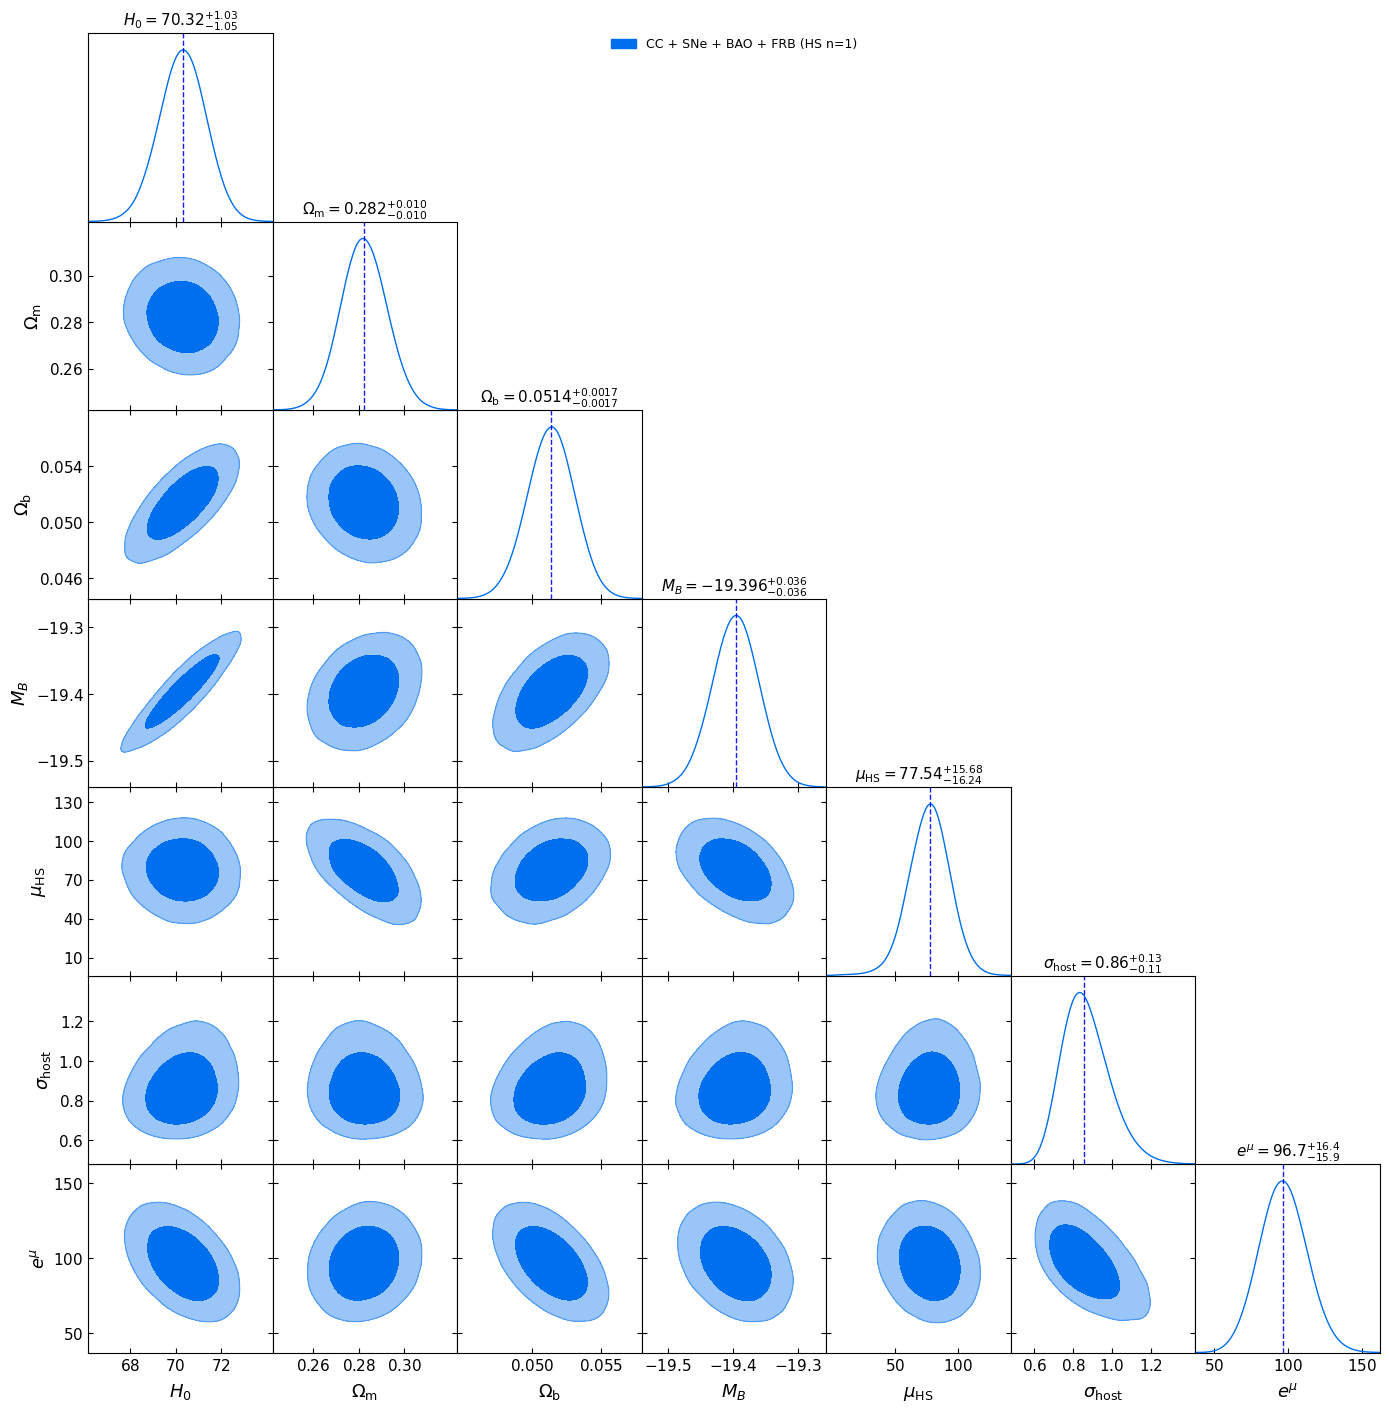

In [12]:
# ====================================================
# Corner plot (GetDist) — mu_HS directly
# ====================================================

param_names  = ["H0", "Om0", "Ob", "MB", "mu_HS", "sigma_host", "exp_mu"]
param_labels = [r"H_0", r"\Omega_{\rm m}", r"\Omega_{\rm b}", r"M_B", r"\mu_\mathrm{HS}",
                r"\sigma_{\rm host}", r"e^\mu"]
fmt_map      = {"H0": ".2f", "Om0": ".3f", "Ob": ".4f", "MB": ".3f", "mu_HS": ".2f", 
                "sigma_host": ".2f", "exp_mu": ".1f"}

samples_gd = MCSamples(
    samples=flat_samples,          
    names=param_names,
    labels=param_labels
)

samples_gd.updateSettings({
    "smooth_scale_1D": 0.25,
    "smooth_scale_2D": 0.25,
    "fine_bins":       1024,
    "fine_bins_2D":    1024,
})

g = plots.get_subplot_plotter()
g.settings.axes_fontsize       = 14
g.settings.lab_fontsize        = 16
g.settings.legend_fontsize     = 12
g.settings.linewidth_contour   = 1.5
g.settings.num_plot_contours   = 2
g.settings.axis_marker_lw      = 1.0
g.settings.figure_legend_frame = False
g.settings.alpha_filled_add    = 0.3

g.triangle_plot(samples_gd, filled=True,
                legend_labels=[f"CC + SNe + BAO + FRB (HS n={n})"],
                title_limit=0)

# Add titles with median ± 68% CL
for i, name in enumerate(param_names):
    samp   = flat_samples[:, i]
    median  = np.percentile(samp, 50)
    lower68 = np.percentile(samp, 16)
    upper68 = np.percentile(samp, 84)
    ep68    = upper68 - median
    em68    = median  - lower68
    ax      = g.subplots[i, i]
    line    = ax.get_lines()[0]
    line.set_linewidth(1.0)
    ax.axvline(median, color="blue", lw=1.0, ls="--", alpha=0.9)
    fmt   = fmt_map[name]
    title = f"${param_labels[i]} = {median:{fmt}}^{{+{ep68:{fmt}}}}_{{-{em68:{fmt}}}}$"
    ax.set_title(title, fontsize=11, pad=4)

plt.subplots_adjust(top=0.95)
figname = f"Corner_HS_n{n}_cc_sne_bao_frb.png"
plt.savefig(figname, dpi=300, bbox_inches="tight")
plt.show()

In [13]:
# ====================================================
# Marginalized statistics
# ====================================================

print("\n" + "="*60)
print(f"{'Final Inference Results (HS n='+str(n)+' | CC + SNe + BAO + FRB data)':^60}")
print("="*60)

for name, idx, fmt in [("H0", 0, ".2f"), ("Om0", 1, ".3f"), ("Ob", 2, ".4f"),
                       ("MB", 3, ".2f"), ("sigma_host", 5, ".2f"), ("exp_mu", 6, ".1f")]:
    samp    = flat_samples[:, idx]
    median  = np.percentile(samp, 50)
    lower68 = np.percentile(samp, 16)
    upper68 = np.percentile(samp, 84)
    lower95 = np.percentile(samp, 2.5)
    upper95 = np.percentile(samp, 97.5)
    ep68 = upper68 - median;  em68 = median - lower68
    ep95 = upper95 - median;  em95 = median - lower95
    print(f"\n  {name}:")
    print(f"    {median:{fmt}} +{ep68:{fmt}} -{em68:{fmt}}  (68% CL)")
    print(f"    {median:{fmt}} +{ep95:{fmt}} -{em95:.{fmt[1:]}}")

# mu_HS — physical
print(f"\n  mu_HS  [physical]:")
samp    = flat_samples[:, 4]
median  = np.percentile(samp, 50)
lower68 = np.percentile(samp, 16)
upper68 = np.percentile(samp, 84)
lower95 = np.percentile(samp, 2.5)
upper95 = np.percentile(samp, 97.5)
ep68 = upper68 - median;  em68 = median - lower68
ep95 = upper95 - median;  em95 = median - lower95
print(f"    {median:.2f} +{ep68:.2f} -{em68:.2f}  (68% CL)")
print(f"    {median:.2f} +{ep95:.2f} -{em95:.2f}  (95% CL)")

# mu_HS_tilde = mu_HS / 100
print(f"\n  mu_HS_tilde  [= mu_HS / 100]:")
samp    = flat_tilde[:, 4]
median  = np.percentile(samp, 50)
lower68 = np.percentile(samp, 16)
upper68 = np.percentile(samp, 84)
lower95 = np.percentile(samp, 2.5)
upper95 = np.percentile(samp, 97.5)
ep68 = upper68 - median;  em68 = median - lower68
ep95 = upper95 - median;  em95 = median - lower95
print(f"    {median:.4f} +{ep68:.4f} -{em68:.4f}  (68% CL)")
print(f"    {median:.4f} +{ep95:.4f} -{em95:.4f}  (95% CL)")

# ln(mu_HS)
print(f"\n  ln(mu_HS)  [= ln(mu_HS)]:")
samp    = flat_ln[:, 4]
median  = np.percentile(samp, 50)
lower68 = np.percentile(samp, 16)
upper68 = np.percentile(samp, 84)
lower95 = np.percentile(samp, 2.5)
upper95 = np.percentile(samp, 97.5)
ep68 = upper68 - median;  em68 = median - lower68
ep95 = upper95 - median;  em95 = median - lower95
print(f"    {median:.3f} +{ep68:.3f} -{em68:.3f}  (68% CL)")
print(f"    {median:.3f} +{ep95:.3f} -{em95:.3f}  (95% CL)")

print("\n" + "="*60)


Final Inference Results (HS n=1 | CC + SNe + BAO + FRB data)

  H0:
    70.32 +1.03 -1.05  (68% CL)
    70.32 +2.00 -2.08

  Om0:
    0.282 +0.010 -0.010  (68% CL)
    0.282 +0.021 -0.020

  Ob:
    0.0514 +0.0017 -0.0017  (68% CL)
    0.0514 +0.0033 -0.0034

  MB:
    -19.40 +0.04 -0.04  (68% CL)
    -19.40 +0.07 -0.07

  sigma_host:
    0.86 +0.13 -0.11  (68% CL)
    0.86 +0.28 -0.20

  exp_mu:
    96.7 +16.4 -15.9  (68% CL)
    96.7 +32.8 -30.8

  mu_HS  [physical]:
    77.54 +15.68 -16.24  (68% CL)
    77.54 +31.21 -33.76  (95% CL)

  mu_HS_tilde  [= mu_HS / 100]:
    0.7754 +0.1568 -0.1624  (68% CL)
    0.7754 +0.3121 -0.3376  (95% CL)

  ln(mu_HS)  [= ln(mu_HS)]:
    4.351 +0.184 -0.235  (68% CL)
    4.351 +0.338 -0.572  (95% CL)



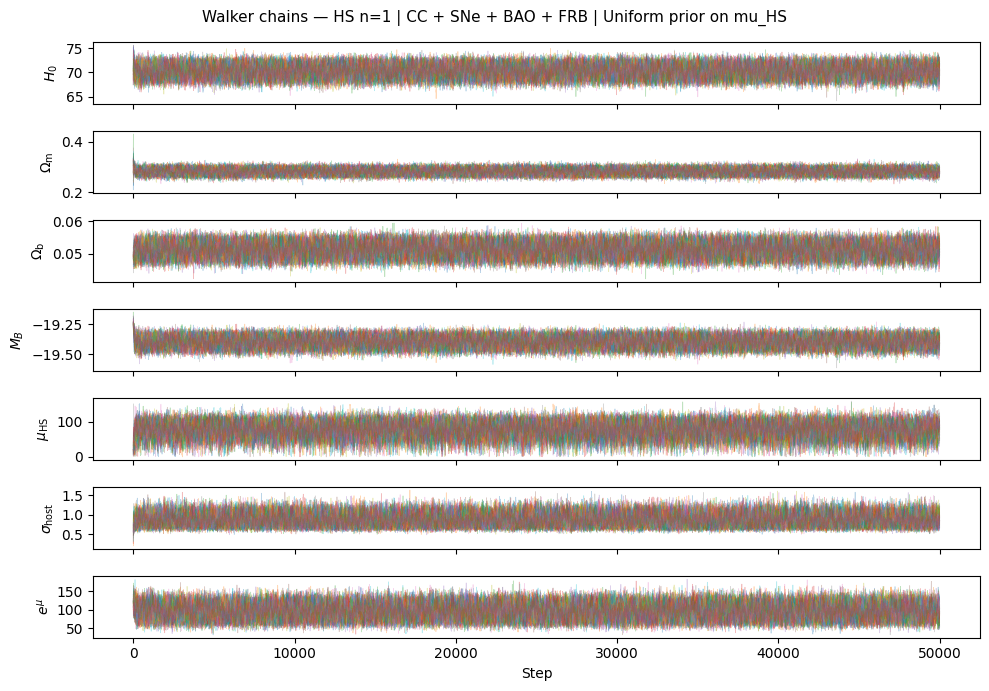

In [14]:
# ====================================================
# Walker chains
# ====================================================

chain_plot   = sampler.get_chain().copy()
chain_labels = [r"$H_0$", r"$\Omega_{\rm m}$", r"$\Omega_{\rm b}$", r"$M_B$",
                r"$\mu_\mathrm{HS}$", r"$\sigma_{\rm host}$", r"$e^\mu$"]

fig, axes = plt.subplots(7, figsize=(10, 7), sharex=True)

for i, label in enumerate(chain_labels):
    axes[i].plot(chain_plot[:, :, i], alpha=0.3, lw=0.5)
    axes[i].set_ylabel(label)
axes[-1].set_xlabel("Step")

plt.suptitle(f"Walker chains — HS n={n} | CC + SNe + BAO + FRB | Uniform prior on mu_HS",
             fontsize=11)

plt.tight_layout()
plt.show()

In [15]:
# ========================================================
# Derived Parameter: Sound Horizon rd
# ========================================================

def compute_rd(H0, Om0, Ob):
    h2   = (H0 / 100.0)**2
    Obh2 = Ob * h2
    Omh2 = Om0 * h2
    rd   = 147.05 * ((Obh2 / 0.02236)**-0.13) \
                  * ((Omh2 / 0.1432)**-0.23)  \
                  * ((Neff  / 3.04)**-0.1)
    return rd

# Compute rd for entire posterior
# flat_samples columns: [H0, Om0, Ob, MB, mu_HS, sigma_host, exp_mu]
rd_chain = np.array([
    compute_rd(s[0], s[1], s[2]) for s in flat_samples
])
mean_rd  = np.mean(rd_chain)
std_rd   = np.std(rd_chain)
lower_95 = np.percentile(rd_chain, 2.5)
upper_95 = np.percentile(rd_chain, 97.5)

print("\n" + "="*60)
print(f"{'Derived Sound Horizon':^60}")
print("="*60)
print(f"  r_d = {mean_rd:.3f} ± {std_rd:.3f} Mpc (68% CL)")
print(f"  95% CL : [{lower_95:.3f}, {upper_95:.3f}] Mpc")
print("="*60)


                   Derived Sound Horizon                    
  r_d = 145.518 ± 2.256 Mpc (68% CL)
  95% CL : [141.223, 150.069] Mpc


In [16]:
# ====================================================
# Model selection statistics
# ====================================================

# Toggle: load samples from file or use sampler from memory
LOAD_FROM_FILE = False   # True = load from .npy | False = use sampler in memory

if LOAD_FROM_FILE:
    fname        = f"flat_samples_HS_n{n}_cc_sne_bao_frb.npy"
    fname_lp     = f"log_prob_HS_n{n}_cc_sne_bao_frb.npy"
    flat_samples  = np.load(fname)
    log_prob_flat = np.load(fname_lp)
    idx_map  = np.argmax(log_prob_flat)
    theta_bf = flat_samples[idx_map]
    print(f"Loaded {len(flat_samples)} samples from {fname}")
    print(f"Best-fit (MAP): {theta_bf}")
else:
    idx_map  = np.argmax(sampler.get_log_prob(discard=nburn, flat=True))
    theta_bf = flat_samples[idx_map]
    print(f"Best-fit (MAP): {theta_bf}")

# flat_samples[:, 4] is already mu_HS — no conversion needed
theta_bf_like = theta_bf.copy()

# Maximum log-likelihood
lnL_max = lnlike_cc_sne_bao_frb(
    theta_bf_like,
    z_cc, H_obs, H_err,
    z_sne, mB_obs, Cinv_sne,
    z_bao, d_obs, q_bao, Cinv_bao,
    z_frb, DM_ext_obs
)

# Number of data points
N_cc  = len(z_cc)
N_sne = len(z_sne)
N_bao = len(z_bao)
N_frb = len(z_frb)
N_tot = N_cc + N_sne + N_bao + N_frb

# Number of free parameters
k = flat_samples.shape[1]

# Chi-squared
chi2     = -2.0 * lnL_max
dof      = N_tot - k
chi2_red = chi2 / dof

# AIC and BIC
AIC = 2.0 * k - 2.0 * lnL_max
BIC = k * np.log(N_tot) - 2.0 * lnL_max

print("\n" + "="*60)
print(f"{'Model Selection Statistics':^60}")
print(f"{'(HS n='+str(n)+' | CC + SNe + BAO + FRB)':^60}")
print("="*60)
print(f"\n  Data points:")
print(f"    CC       : {N_cc}")
print(f"    SNe      : {N_sne}")
print(f"    BAO      : {N_bao}")
print(f"    FRB      : {N_frb}")
print(f"    Total    : {N_tot}")
print(f"\n  Free parameters (k) : {k}")
print(f"  Degrees of freedom  : {dof}")
print(f"\n  ln L_max  = {lnL_max:.4f}")
print(f"  χ²        = {chi2:.4f}")
print(f"  χ²/dof    = {chi2_red:.4f}")
print(f"  AIC       = {AIC:.4f}")
print(f"  BIC       = {BIC:.4f}")
print("\n" + "="*60)

Best-fit (MAP): [ 7.01506171e+01  2.80942104e-01  5.11731726e-02 -1.94038104e+01
  8.01936942e+01  8.40152015e-01  9.71482174e+01]

                 Model Selection Statistics                 
              (HS n=1 | CC + SNe + BAO + FRB)               

  Data points:
    CC       : 35
    SNe      : 1588
    BAO      : 13
    FRB      : 104
    Total    : 1740

  Free parameters (k) : 7
  Degrees of freedom  : 1733

  ln L_max  = -1378.2402
  χ²        = 2756.4804
  χ²/dof    = 1.5906
  AIC       = 2770.4804
  BIC       = 2808.7119

